# FF Model Debug Notebook

This notebook has two goals:
1. Load validation data from the FF TFRecord training set, run the trained model, and compare prediction vs ground truth.
2. Load experimental GISAXS data, build the same mask style used in the testCode notebook, create `masked_data`, and inspect the model output on the masked experiment input.

In [ ]:
from pathlib import Path

TRAINSET_DIR = Path('/data/dust/user/zhaiyufe/TrainSet/ML_GISAXS_Yuxin')
RESULTS_DIR = Path('/data/dust/user/zhaiyufe/Models/ML_GISAXS_Yuxin/Results_FF/poisson_1p0_20p0')
MODEL_NAME = 'yuxin_ff_model_softmax_poisson_1p0_20p0'
PATH_MODEL = RESULTS_DIR / f'{MODEL_NAME}.keras'
PATH_CHECKPOINT = RESULTS_DIR / f'{MODEL_NAME}.checkpoint.keras'
MASK_PATH = Path('/home/zhaiyufe/PycharmProjects/ML_GISAXS_Yuxin/TrainingNet/mask.npy')

SAMPLE_COUNT = 10
N_PLOT_SAMPLES = 5
RANDOM_SEED = 42
INPUT_MODE = 'clean'
APPLY_FIXED_MASK = True
LOG_EPS = 1e-8

CBF_FILE_PATTERN = '/data/dust/user/zhaiyufe/experimentData/Yuxin/lyx_cu_peo1_20pl_2p5fr_116_00002/p2m/lyx_cu_peo1_20pl_2p5fr_116_00002_{sequence_number:05d}.cbf'
SEQUENCE_START = 10
SEQUENCE_END = 35
CROP_PARAMS = [670, 1100, 300, 530]  # [left, up, down, right]
DETECTOR_DISTANCE_MM = 3230.0
THETA_IN_DEG = 0.4
WAVELENGTH_NM = 0.105
PIXEL_SIZE_MM = 0.172
BEAM_CENTER_PIXEL = (804, 305)
BEAMSTOPS = [
    {'center': (0, 270), 'radius': 30},
    {'center': (246, 256), 'radius': 20},
]

In [ ]:
import os
import sys
import glob
import random

import fabio
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from scipy.ndimage import zoom, median_filter, binary_dilation, binary_fill_holes
from tensorflow.keras.models import load_model

os.environ.setdefault('TF_XLA_FLAGS', '--tf_xla_enable_xla_devices=false')
os.environ.setdefault('XLA_FLAGS', '--xla_gpu_cuda_data_dir=/software/cuda/cuda-12.3')
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '2')

for device in tf.config.list_physical_devices('GPU'):
    try:
        tf.config.experimental.set_memory_growth(device, True)
    except Exception:
        pass

candidate_dirs = [
    Path.cwd(),
    Path('/home/zhaiyufe/PycharmProjects/ML_GISAXS_Yuxin/TrainingNet'),
]
project_dir = None
for candidate in candidate_dirs:
    if (candidate / 'tools').exists():
        project_dir = candidate
        break

if project_dir is None:
    raise FileNotFoundError('Could not locate the TrainingNet/tools directory.')

tools_dir = project_dir / 'tools'
if str(tools_dir) not in sys.path:
    sys.path.insert(0, str(tools_dir))

from Detector import Detector

np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

model_path = PATH_MODEL if PATH_MODEL.exists() else PATH_CHECKPOINT
if not model_path.exists():
    raise FileNotFoundError(f'Model not found: {model_path}')
if APPLY_FIXED_MASK and not MASK_PATH.exists():
    raise FileNotFoundError(f'Mask file not found: {MASK_PATH}')

print(f'Using project_dir: {project_dir}')
print(f'Using model path: {model_path}')
print(f'Using mask path: {MASK_PATH}')
print('Visible GPUs:', tf.config.list_physical_devices('GPU'))

FileNotFoundError: Model not found: C:\Users\zhaiyufe\Downloads\YX_Cu_Si_Sputter_Model\YX_Cu_Si_Sputter_Model\yuxin_ff_model_softmax_poisson_1p0_20p0.checkpoint.keras

selected_folder = /data/dust/user/zhaiyufe/TrainSet/ML_GISAXS_Yuxin/tCu_24.107__tPoly_15.714
num_selected_files = 1
input_data_shape = (256, 256, 1)
output_data_shape = (30, 30)
actual_sample_count = 10


The dtype policy mixed_float16 may run slowly because this machine does not have a GPU. Only Nvidia GPUs with compute capability of at least 7.0 run quickly with mixed_float16.
If you will use compatible GPU(s) not attached to this host, e.g. by running a multi-worker model, you can ignore this warning. This message will only be logged once


raw input min/max = 0.035086024552583694 249.5417938232422
preprocessed input min/max = -7.518592834472656 1.0000001192092896
prediction nan count = 0
sample_mse = [3.1458323e-05 8.6978416e-06 6.5072936e-06 5.5310184e-06 1.6845131e-06
 9.1730266e-07 1.7658555e-06 2.1587289e-06 4.6426753e-06 1.6197971e-06]
mean_mse = 6.4983346419467125e-06
std_mse = 8.669299859320745e-06
prediction finite ratio = 1.0


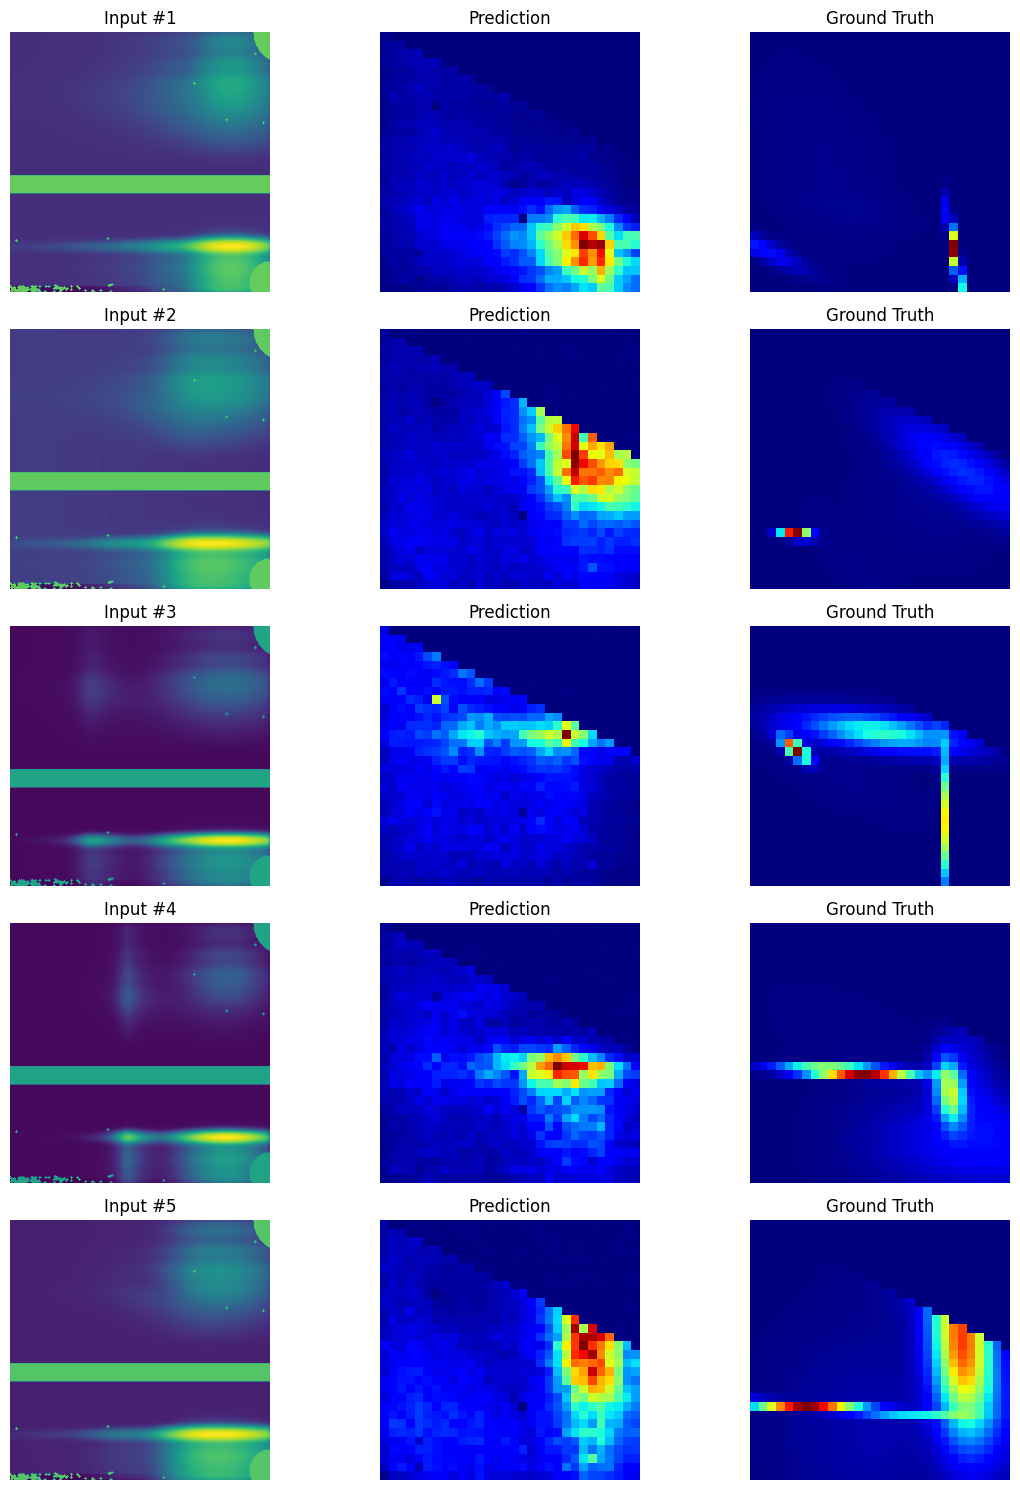

In [4]:
def infer_shapes_from_tfrecord(filename):
    for raw in tf.data.TFRecordDataset(filename).take(1):
        example = tf.train.Example()
        example.ParseFromString(raw.numpy())
        input_len = len(example.features.feature['input'].float_list.value)
        output_len = len(example.features.feature['output'].float_list.value)

    input_side = int(round(input_len ** 0.5))
    output_side = int(round(output_len ** 0.5))
    input_shape = (input_side, input_side, 1)
    output_shape = (output_side, output_side)
    return input_shape, output_shape


def load_mask_array(mask_path, image_shape):
    if not mask_path.exists():
        raise FileNotFoundError(f'Mask file not found: {mask_path}')
    if mask_path.suffix == '.npz':
        npz = np.load(mask_path)
        mask = np.array(npz['mask']) if 'mask' in npz else np.array(npz[npz.files[0]])
    else:
        mask = np.load(mask_path)
    if mask.ndim == 2:
        mask = mask[..., None]
    if mask.shape != image_shape:
        raise ValueError(f'Mask shape {mask.shape} does not match input shape {image_shape}')
    return mask.astype(bool)


def log_normalize_np(image, log_eps=LOG_EPS):
    image = np.asarray(image, dtype=np.float32)
    max_val = np.max(image)
    scale = np.e / (max_val + log_eps)
    scaled = image * scale
    logged = np.log(scaled + log_eps)
    logged[~np.isfinite(logged)] = -1.0
    return logged.astype(np.float32)


def preprocess_clean_input_np(image, fixed_mask=None):
    processed = log_normalize_np(image)
    if fixed_mask is not None:
        processed = np.where(fixed_mask, -1.0, processed)
    return processed.astype(np.float32)


def make_parser(input_shape, output_shape):
    def parse_example(example_proto):
        feature_description = {
            'input': tf.io.FixedLenFeature(input_shape, tf.float32),
            'output': tf.io.FixedLenFeature(output_shape, tf.float32),
        }
        return tf.io.parse_single_example(example_proto, feature_description)

    return parse_example


def replace_nan_with_zero(parsed_record):
    parsed_record['input'] = tf.where(
        tf.math.is_nan(parsed_record['input']),
        tf.zeros_like(parsed_record['input']),
        parsed_record['input'],
    )
    parsed_record['output'] = tf.where(
        tf.math.is_nan(parsed_record['output']),
        tf.zeros_like(parsed_record['output']),
        parsed_record['output'],
    )
    return parsed_record


def load_ff_dataset(file_list, input_shape, output_shape):
    dataset = tf.data.TFRecordDataset(file_list)
    dataset = dataset.map(make_parser(input_shape, output_shape), num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.map(replace_nan_with_zero, num_parallel_calls=tf.data.AUTOTUNE)
    return dataset


def plot_prediction_grid(inputs, predictions, ground_truth, max_plots=5):
    plot_count = min(len(inputs), max_plots)
    fig, axes = plt.subplots(plot_count, 3, figsize=(12, 3 * plot_count))
    if plot_count == 1:
        axes = np.expand_dims(axes, axis=0)

    for idx in range(plot_count):
        axes[idx, 0].imshow(inputs[idx].squeeze(), cmap='viridis')
        axes[idx, 0].set_title(f'Input #{idx + 1}')
        axes[idx, 1].imshow(predictions[idx], cmap='jet')
        axes[idx, 1].set_title('Prediction')
        axes[idx, 2].imshow(ground_truth[idx], cmap='jet')
        axes[idx, 2].set_title('Ground Truth')
        for ax in axes[idx]:
            ax.axis('off')

    plt.tight_layout()


def summarize_prediction_error(predictions, ground_truth):
    sample_mse = np.mean((predictions - ground_truth) ** 2, axis=(1, 2))
    print('sample_mse =', sample_mse)
    print('mean_mse =', float(sample_mse.mean()))
    print('std_mse =', float(sample_mse.std()))
    print('prediction finite ratio =', float(np.isfinite(predictions).mean()))


def plot_distribution_with_profiles(distribution, title='Predicted FF distribution'):
    distribution = np.asarray(distribution)
    vertical_sum = distribution.sum(axis=0)
    horizontal_sum = distribution.sum(axis=1)

    fig, axes = plt.subplots(2, 2, figsize=(10, 10), gridspec_kw={'width_ratios': [4, 1], 'height_ratios': [1, 4]})
    im = axes[1, 0].imshow(distribution, cmap='jet')
    axes[1, 0].set_title(title)
    axes[1, 0].axis('off')

    axes[0, 0].plot(vertical_sum, color='red', linewidth=2)
    axes[0, 0].set_title('h profile')
    axes[0, 0].grid(True, linestyle='--', linewidth=0.5)

    axes[1, 1].plot(horizontal_sum, np.arange(len(horizontal_sum)), color='red', linewidth=2)
    axes[1, 1].set_title('R profile')
    axes[1, 1].invert_yaxis()
    axes[1, 1].grid(True, linestyle='--', linewidth=0.5)

    axes[0, 1].axis('off')
    fig.colorbar(im, ax=axes[1, 0], fraction=0.046, pad=0.04)
    plt.tight_layout()

    total_mass = distribution.sum()
    peak_index = np.unravel_index(np.argmax(distribution), distribution.shape)
    print(f'total_mass = {total_mass:.6f}')
    print(f'peak_index = {peak_index}')


all_tfrecords = sorted(glob.glob(str(TRAINSET_DIR / '**' / '*_ff.tfrecord'), recursive=True))
if not all_tfrecords:
    raise FileNotFoundError(f'No *_ff.tfrecord files found under {TRAINSET_DIR}')

folder_candidates = sorted({str(Path(path).parent) for path in all_tfrecords})
rng = random.Random(RANDOM_SEED)
selected_folder = Path(rng.choice(folder_candidates))
selected_files = sorted(glob.glob(str(selected_folder / '*_ff.tfrecord')))

print('selected_folder =', selected_folder)
print('num_selected_files =', len(selected_files))

input_data_shape, output_data_shape = infer_shapes_from_tfrecord(selected_files[0])
print('input_data_shape =', input_data_shape)
print('output_data_shape =', output_data_shape)

fixed_mask = load_mask_array(MASK_PATH, input_data_shape) if APPLY_FIXED_MASK else None

dataset = load_ff_dataset(selected_files, input_data_shape, output_data_shape)
dataset = dataset.shuffle(buffer_size=2048, seed=RANDOM_SEED, reshuffle_each_iteration=False)
sample_records = list(dataset.take(SAMPLE_COUNT))

if not sample_records:
    raise ValueError(f'No samples found in {selected_folder}')

actual_sample_count = len(sample_records)
print('actual_sample_count =', actual_sample_count)

raw_inputs = np.stack([record['input'].numpy() for record in sample_records], axis=0).astype(np.float32)
inputs = np.stack([preprocess_clean_input_np(record['input'].numpy(), fixed_mask=fixed_mask) for record in sample_records], axis=0).astype(np.float32)
ground_truth = np.stack([record['output'].numpy() for record in sample_records], axis=0).astype(np.float32)

model = load_model(model_path)
predictions = model.predict(inputs, verbose=0)

print('raw input min/max =', float(raw_inputs.min()), float(raw_inputs.max()))
print('preprocessed input min/max =', float(inputs.min()), float(inputs.max()))
print('prediction nan count =', int(np.isnan(predictions).sum()))

summarize_prediction_error(predictions, ground_truth)
plot_prediction_grid(inputs, predictions, ground_truth, max_plots=N_PLOT_SAMPLES)

In [5]:
def resize_matrix(matrix, new_shape):
    zoom_factors = [new_dim / float(old_dim) for new_dim, old_dim in zip(new_shape, matrix.shape)]
    return zoom(matrix, zoom_factors, order=0)


def circular_mask(shape, center, radius):
    height, width = shape
    y, x = np.ogrid[:height, :width]
    cy, cx = center
    return (x - cx) ** 2 + (y - cy) ** 2 <= radius ** 2


def build_gisaxs_mask(
    data,
    beamstops=None,
    gap_value_threshold=1e-12,
    row_gap_fraction=0.8,
    col_gap_fraction=0.8,
    bad_sigma=1e6,
    median_size=5,
    dilate_iter=1,
):
    data = np.asarray(data)
    invalid = ~np.isfinite(data) | (data <= gap_value_threshold)

    row_bad = np.mean(invalid, axis=1) > row_gap_fraction
    col_bad = np.mean(invalid, axis=0) > col_gap_fraction

    gap_mask = invalid.copy()
    gap_mask[row_bad, :] = True
    gap_mask[:, col_bad] = True

    safe_data = data.copy()
    finite_vals = np.isfinite(safe_data)
    fill_value = np.nanmedian(safe_data[finite_vals]) if np.any(finite_vals) else 0.0
    safe_data[~finite_vals] = fill_value

    med = median_filter(safe_data, size=median_size)
    resid = safe_data - med
    valid_for_stats = ~gap_mask & np.isfinite(resid)

    if np.any(valid_for_stats):
        mad = np.median(np.abs(resid[valid_for_stats] - np.median(resid[valid_for_stats])))
        robust_sigma = 1.4826 * mad if mad > 0 else np.std(resid[valid_for_stats])
    else:
        robust_sigma = 0.0

    if robust_sigma > 0:
        badpixel_mask = np.abs(resid) > (bad_sigma * robust_sigma)
    else:
        badpixel_mask = np.zeros_like(data, dtype=bool)

    beamstop_mask = np.zeros_like(data, dtype=bool)
    if beamstops is not None:
        for bs in beamstops:
            beamstop_mask |= circular_mask(data.shape, bs['center'], bs['radius'])

    mask = gap_mask | badpixel_mask | beamstop_mask
    if dilate_iter > 0:
        mask = binary_dilation(mask, iterations=dilate_iter)
    mask = binary_fill_holes(mask)
    return mask


def display_summed_images(start_sequence, end_sequence, file_pattern):
    summed_data = None
    for sequence_number in range(start_sequence, end_sequence + 1):
        cbf_file = file_pattern.format(sequence_number=sequence_number)
        cbf_image = fabio.open(cbf_file)
        data = cbf_image.data.astype(np.float32)
        summed_data = data if summed_data is None else (summed_data + data)

    if summed_data is None:
        raise ValueError('No CBF data was loaded. Check file_pattern and sequence range.')

    return summed_data


def get_detector_grids(crop_params, output_size=(256, 256)):
    left, up, down, right = crop_params
    detector_params = [
        output_size[1],
        (1475 - left - right) * PIXEL_SIZE_MM,
        output_size[0],
        (1679 - up - down) * PIXEL_SIZE_MM,
    ]
    beam_center = [
        (BEAM_CENTER_PIXEL[0] - right) * PIXEL_SIZE_MM,
        (BEAM_CENTER_PIXEL[1] - down) * PIXEL_SIZE_MM,
    ]

    detector = Detector(
        detector_params,
        beam_center.copy(),
        DETECTOR_DISTANCE_MM,
        THETA_IN_DEG,
        WAVELENGTH_NM,
    )
    _, _, qz, qr = detector.calculate_q_vectors()
    return qr, qz


def prepare_experiment_input(masked_data, experiment_mask, fixed_mask):
    finite_vals = masked_data[np.isfinite(masked_data)]
    if finite_vals.size == 0:
        raise ValueError('masked_data contains no finite values.')

    fill_value = np.nanmax(finite_vals)
    filled_data = masked_data.copy()
    filled_data[~np.isfinite(filled_data)] = fill_value
    filled_data[filled_data < 0] = fill_value

    model_input_2d = log_normalize_np(filled_data)
    combined_mask = experiment_mask.copy()
    if fixed_mask is not None:
        combined_mask = combined_mask | fixed_mask.squeeze(-1)
    model_input_2d[combined_mask] = -1.0

    model_input = model_input_2d[np.newaxis, ..., np.newaxis].astype(np.float32)
    return model_input, model_input_2d, combined_mask

raw_data.shape = (1679, 1475)


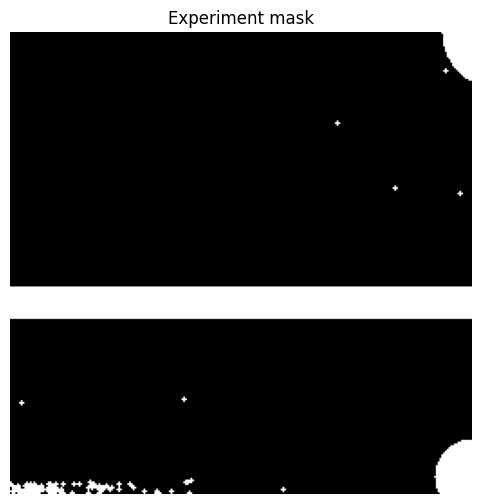

/tmp/ipykernel_2712698/313368091.py:23: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(cropped_qr, cropped_qz, np.log(masked_data), cmap='viridis', shading='auto')


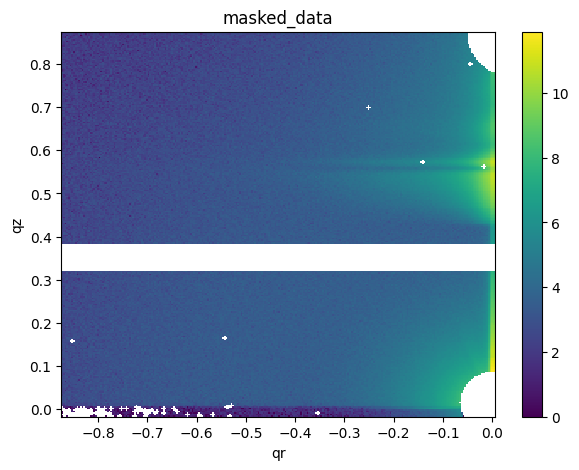

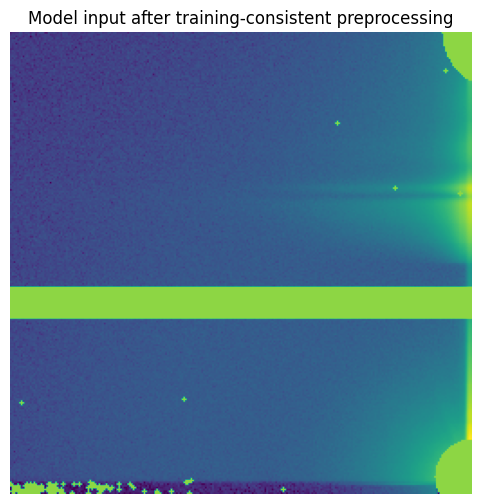

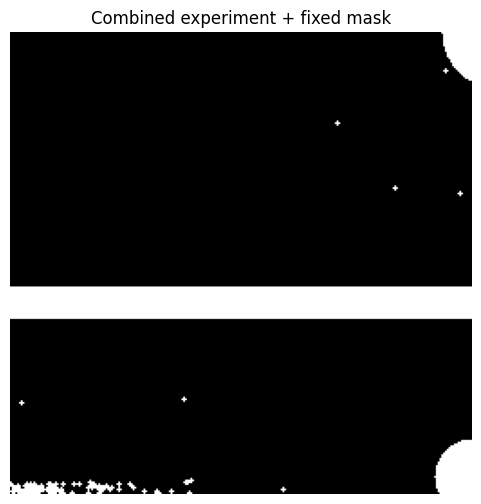

experiment input min/max = -10.886963844299316 1.0
experiment prediction nan count = 0
total_mass = 1.000977
peak_index = (8, 6)


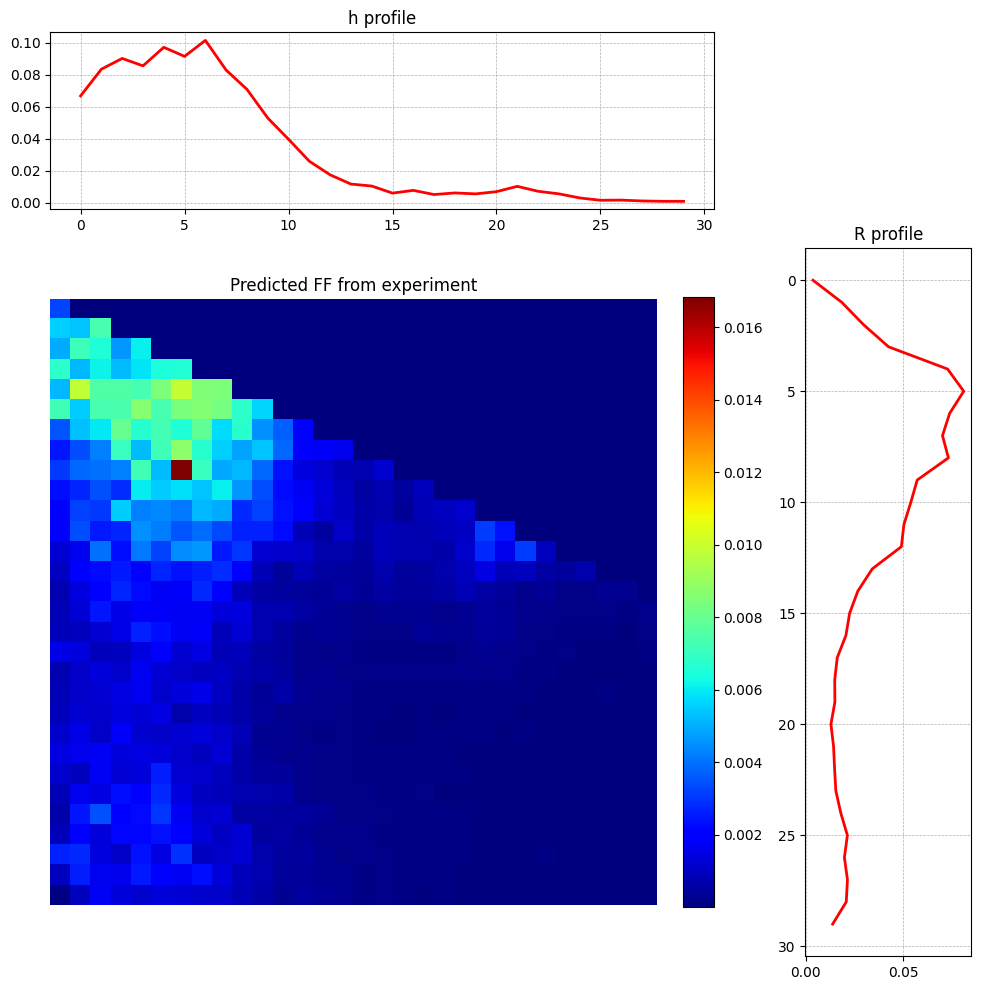

In [6]:
raw_data = display_summed_images(SEQUENCE_START, SEQUENCE_END, CBF_FILE_PATTERN)
print('raw_data.shape =', raw_data.shape)

left, up, down, right = CROP_PARAMS
cropped_raw = raw_data[up:-down, right:-left]
cropped_data = resize_matrix(cropped_raw, input_data_shape[:2]).astype(np.float32)
cropped_qr, cropped_qz = get_detector_grids(CROP_PARAMS, output_size=input_data_shape[:2])

experiment_mask = build_gisaxs_mask(
    cropped_data,
    gap_value_threshold=0,
    beamstops=BEAMSTOPS,
)

plt.figure(figsize=(6, 6))
plt.imshow(experiment_mask, cmap='gray')
plt.title('Experiment mask')
plt.axis('off')
plt.show()

masked_data = np.where(experiment_mask, np.nan, cropped_data)
plt.figure(figsize=(7, 5))
plt.pcolormesh(cropped_qr, cropped_qz, np.log(masked_data), cmap='viridis', shading='auto')
plt.title('masked_data')
plt.xlabel('qr')
plt.ylabel('qz')
plt.colorbar()
plt.show()

model_input, model_input_2d, combined_mask = prepare_experiment_input(masked_data, experiment_mask, fixed_mask)
prediction_experiment = model.predict(model_input, verbose=0)[0]

plt.figure(figsize=(6, 6))
plt.imshow(model_input_2d, cmap='viridis')
plt.title('Model input after training-consistent preprocessing')
plt.axis('off')
plt.show()

plt.figure(figsize=(6, 6))
plt.imshow(combined_mask, cmap='gray')
plt.title('Combined experiment + fixed mask')
plt.axis('off')
plt.show()

print('experiment input min/max =', float(model_input.min()), float(model_input.max()))
print('experiment prediction nan count =', int(np.isnan(prediction_experiment).sum()))
plot_distribution_with_profiles(prediction_experiment, title='Predicted FF from experiment')

In [11]:
# Validate: module preprocess:run vs current notebook preprocessing
import importlib.util
import yaml
from pathlib import Path
import numpy as np

module_dir = Path('/home/zhaiyufe/PycharmProjects/ML_GISAXS_Yuxin/TrainSetBuild/Model_Yuxin')
module_yaml_path = module_dir / 'module.yaml'
module_py_path = module_dir / 'preprocess.py'

if not module_yaml_path.exists():
    raise FileNotFoundError(f'Module yaml not found: {module_yaml_path}')
if not module_py_path.exists():
    raise FileNotFoundError(f'Module preprocess.py not found: {module_py_path}')

with open(module_yaml_path, 'r', encoding='utf-8') as f:
    module_cfg = yaml.safe_load(f)
preprocess_cfg = module_cfg.get('preprocess', {})

spec = importlib.util.spec_from_file_location('model_yuxin_preprocess', str(module_py_path))
module_preprocess = importlib.util.module_from_spec(spec)
spec.loader.exec_module(module_preprocess)

# IMPORTANT: module pipeline includes its own crop+resize, so feed raw_data here.
if 'raw_data' not in globals() or raw_data is None:
    raw_data = display_summed_images(SEQUENCE_START, SEQUENCE_END, CBF_FILE_PATTERN)

module_out, module_steps = module_preprocess.run(
    raw_data,
    preprocess_cfg=preprocess_cfg,
    module_folder=str(module_dir),
    return_steps=True,
)

# Compare against notebook path output (already built from raw_data in cell 6)
expected_input_2d = model_input_2d.astype(np.float32)
module_out = module_out.astype(np.float32)

# 1) Compare input image tensor (2D)
img_abs_diff = np.abs(module_out - expected_input_2d)
img_max_abs_diff = float(np.nanmax(img_abs_diff))
img_mean_abs_diff = float(np.nanmean(img_abs_diff))
img_allclose = bool(np.allclose(module_out, expected_input_2d, rtol=0.0, atol=1e-7, equal_nan=True))

print('=== preprocess image comparison ===')
print('module_out shape =', module_out.shape, 'expected shape =', expected_input_2d.shape)
print('image max_abs_diff =', img_max_abs_diff)
print('image mean_abs_diff =', img_mean_abs_diff)
print('image allclose(atol=1e-7) =', img_allclose)

# 2) Compare masked positions (-1.0) vs notebook combined_mask
module_mask = np.isclose(module_out, -1.0)
notebook_mask = combined_mask.astype(bool)
mask_xor = np.logical_xor(module_mask, notebook_mask)
mask_mismatch_count = int(mask_xor.sum())
mask_total = int(module_mask.size)
mask_mismatch_ratio = float(mask_mismatch_count / mask_total)

print('\n=== mask comparison ===')
print('module masked count =', int(module_mask.sum()))
print('notebook masked count =', int(notebook_mask.sum()))
print('mask mismatch count =', mask_mismatch_count)
print('mask mismatch ratio =', mask_mismatch_ratio)
print('mask exact match =', bool(mask_mismatch_count == 0))

# 3) Compare model predictions generated from each input path
module_input = module_out[np.newaxis, ..., np.newaxis].astype(np.float32)
pred_module = model.predict(module_input, verbose=0)[0].astype(np.float32)
pred_notebook = prediction_experiment.astype(np.float32)
pred_abs_diff = np.abs(pred_module - pred_notebook)
pred_max_abs_diff = float(np.nanmax(pred_abs_diff))
pred_mean_abs_diff = float(np.nanmean(pred_abs_diff))
pred_allclose = bool(np.allclose(pred_module, pred_notebook, rtol=0.0, atol=1e-7, equal_nan=True))

print('\n=== prediction comparison ===')
print('prediction max_abs_diff =', pred_max_abs_diff)
print('prediction mean_abs_diff =', pred_mean_abs_diff)
print('prediction allclose(atol=1e-7) =', pred_allclose)

print('\n=== module steps executed ===')
print([step['step'] for step in module_steps])

if img_allclose and (mask_mismatch_count == 0) and pred_allclose:
    print('\n✅ Module preprocess:run is fully consistent with notebook preprocessing output.')
else:
    print('\n⚠️ Differences detected. Check crop/mask params and step order in module.yaml vs notebook logic.')

=== preprocess image comparison ===
module_out shape = (256, 256) expected shape = (256, 256)
image max_abs_diff = 0.0
image mean_abs_diff = 0.0
image allclose(atol=1e-7) = True

=== mask comparison ===
module masked count = 5778
notebook masked count = 5778
mask mismatch count = 0
mask mismatch ratio = 0.0
mask exact match = True

=== prediction comparison ===
prediction max_abs_diff = 0.0
prediction mean_abs_diff = 0.0
prediction allclose(atol=1e-7) = True

=== module steps executed ===
['crop', 'resize', 'experiment_mask', 'log_and_normalize', 'mask']

✅ Module preprocess:run is fully consistent with notebook preprocessing output.


In [12]:
print('predictions.shape =', predictions.shape)
print('ground_truth.shape =', ground_truth.shape)
print('prediction min/max/mean =', float(predictions.min()), float(predictions.max()), float(predictions.mean()))
print('ground_truth min/max/mean =', float(ground_truth.min()), float(ground_truth.max()), float(ground_truth.mean()))

prediction_sample_mse = np.mean((predictions - ground_truth) ** 2, axis=(1, 2))
zero_baseline = np.zeros_like(ground_truth)
zero_baseline_mse = np.mean((zero_baseline - ground_truth) ** 2, axis=(1, 2))

print('prediction_sample_mse =', prediction_sample_mse)
print('zero_baseline_mse =', zero_baseline_mse)
print('mean prediction mse =', float(prediction_sample_mse.mean()))
print('mean zero-baseline mse =', float(zero_baseline_mse.mean()))

for index in range(min(3, len(predictions))):
    print(f'sample {index}: pred_sum={float(predictions[index].sum()):.6f}, gt_sum={float(ground_truth[index].sum()):.6f}, pred_max={float(predictions[index].max()):.6f}, gt_max={float(ground_truth[index].max()):.6f}')

print('experiment prediction min/max/mean =', float(prediction_experiment.min()), float(prediction_experiment.max()), float(prediction_experiment.mean()), float(prediction_experiment.sum()))

predictions.shape = (10, 30, 30)
ground_truth.shape = (10, 30, 30)
prediction min/max/mean = 9.000301361083984e-06 0.01212310791015625 0.0011110305786132812
ground_truth min/max/mean = 0.0 0.10148201137781143 0.0011111111380159855
prediction_sample_mse = [3.1458323e-05 8.6978416e-06 6.5072936e-06 5.5310184e-06 1.6845131e-06
 9.1730266e-07 1.7658555e-06 2.1587289e-06 4.6426753e-06 1.6197971e-06]
zero_baseline_mse = [3.7385576e-05 1.2994314e-05 1.0113508e-05 8.3779396e-06 6.3100902e-06
 3.7236052e-06 4.1152739e-06 4.9514897e-06 5.9925128e-06 4.6117639e-06]
mean prediction mse = 6.4983346419467125e-06
mean zero-baseline mse = 9.857607437879778e-06
sample 0: pred_sum=0.999512, gt_sum=1.000000, pred_max=0.011650, gt_max=0.101482
sample 1: pred_sum=1.000977, gt_sum=1.000000, pred_max=0.008659, gt_max=0.058671
sample 2: pred_sum=1.000000, gt_sum=1.000000, pred_max=0.012123, gt_max=0.028607
experiment prediction min/max/mean = 3.4570693969726562e-06 0.0168304443359375 0.0011119842529296875 1.0